# Mar Menor — Live Earth-Observation Session (60 min)

**Earth-Observation Workshop · Mar Menor coastal lagoon (Murcia, Spain) · NYU PhD**

---

**In August 2021, the Mar Menor turned green and three tonnes of dead fish washed
up on its shores.** Europe's largest coastal lagoon had suffocated — an algal
bloom, fed by decades of farm runoff and triggered by a marine heatwave, had
stripped the water of oxygen. It made national news. And every stage of it was
recorded, from orbit, at 10 metres per pixel — freely available to anyone.

In the next hour **you** will pull that data with your own hands and watch the
crisis appear on your screen: browse the lagoon from space, download real
Sentinel-2 imagery, measure the bloom, add live pollution data, and even train a
detector that flags the crisis on its own. No prior remote-sensing experience,
and **nothing to install** — it all runs in your browser on Google Colab.

> This is the main session. Three deeper notebooks (satellite retrieval, in-situ
> + machine learning, and building your own database) come as **optional extra
> material** — linked at the end.

## What we'll do (≈55 min + questions)

| # | Step | You get |
|---|------|---------|
| 1 | **Browse** any date with NASA GIBS | A true-colour image of the lagoon |
| 2 | **Download** real Sentinel-2 (10 m) | The real view + the individual bands |
| 3 | **Measure** the bloom with NDCI | The chlorophyll map of the 2021 crisis |
| 4 | **Add pollution context** (air quality) | A live PM2.5 / ozone series |
| 5 | **(Optional) your Copernicus key** | On-demand products from the server |
| 6 | **A taste of machine learning** | A detector that finds the crises by itself |
| 7 | **Build a tiny database** | Your measurement, stored & queried in SQL |

> Steps 6–7 are short previews of the two deep-dive notebooks (**02 — in-situ +
> ML** and **03 — build your own database**). The full versions are linked at the end.

## How to run

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RicardoTeruelGutierrez/marmenor-eo-workshop/blob/main/notebooks/00_live_session.ipynb)

- **In Colab:** click the badge, then **Runtime → Run all**. The first cell installs everything (~30 s).
- **Run cells in order**, top to bottom.
- **Cell labels:** 🟢 **RUN** = just run it · ✏️ **EDIT** = change one value first · ⏭️ **OPTIONAL** = safe to skip.


---
## Setup — run this first  🟢

This first cell does the boring-but-essential plumbing so the rest of the session
just works:

- **Installs the libraries** we need (only in Colab — on your own machine they're
  already there). The key one is `rasterio`, the standard Python library for
  reading satellite raster files.
- **Defines our study area.** In Earth observation you almost always start by
  drawing a box on the planet. Ours is the Mar Menor, written as a *bounding box*:
  the minimum and maximum longitude and latitude, in plain decimal degrees
  (the **WGS84** system your phone's GPS uses). Those four numbers are the only
  thing you'd change to study a different place.
- **Checks if you're online.** Every "live" step fetches real data over the
  internet; if there's no connection the notebook says so instead of crashing.

Run it and you should see *"Setup complete"* with your study area printed back.


In [1]:
# Colab bootstrap (does nothing on a local install)
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q rasterio requests matplotlib numpy pandas pyarrow scikit-learn

import io, sqlite3, requests
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.rcParams.update({"figure.dpi": 120})

# Small helper: load a workshop dataset locally, or fetch it from the repo.
# Lets this single notebook reach the synthetic series for Steps 6-7 without a
# full clone — works the same in Colab and on your laptop.
RAW = ("https://raw.githubusercontent.com/RicardoTeruelGutierrez/"
       "marmenor-eo-workshop/main/data")
def load_parquet(name):
    local = Path("../data") / name
    if local.exists():
        return pd.read_parquet(local)
    r = requests.get(f"{RAW}/{name}", timeout=60); r.raise_for_status()
    return pd.read_parquet(io.BytesIO(r.content))

# Study area (WGS84): the Mar Menor lagoon. Change to study anywhere on Earth.
AOI  = dict(lon_min=-0.882, lon_max=-0.700, lat_min=37.598, lat_max=37.812)
BBOX = (AOI["lon_min"], AOI["lat_min"], AOI["lon_max"], AOI["lat_max"])
LAGOON_LON, LAGOON_LAT = -0.79, 37.70    # a point inside the lagoon

def online():
    try: requests.head("https://earth-search.aws.element84.com", timeout=5); return True
    except Exception: return False
ONLINE = online()

print("Setup complete.")
print(f"  Study area : {BBOX}")
print(f"  Internet   : {'yes - live downloads will work' if ONLINE else 'no - will note where data would arrive'}")


Setup complete.
  Study area : (-0.882, 37.598, -0.7, 37.812)
  Internet   : yes - live downloads will work


---
## Before we download: do I need an account?  📋

A common first question — *"don't I need to sign up for satellite data?"* The
honest answer: **for most of what we do today, no.** A lot of Earth-observation
data is genuinely open and downloads with a plain web request. A few richer
services need a free account. Here is the whole landscape, and exactly what *this*
session uses:

| Source | Account? | How to get access | Used in |
|--------|----------|-------------------|---------|
| **NASA GIBS** (browse imagery) | ❌ none | just a URL (WMS) | **Step 1** |
| **Earth Search + AWS Open Data** (Sentinel-2 COGs) | ❌ none | anonymous HTTP | **Step 2–3** |
| **Open-Meteo** (air quality, marine) | ❌ none | keyless REST API | **Step 4** |
| **Copernicus CDSE / Sentinel Hub** (on-demand processing) | ✅ free | register → create an *OAuth client* → use ID+secret | **Step 5** |
| **NASA Earthdata** (MODIS/VIIRS archives) | ✅ free | register → login token (`earthaccess`) | not today |
| **Copernicus Marine** (ocean model data) | ✅ free | register → `copernicusmarine login` | not today |

**Two ways services let code in:**

- **No login** — the data sits on a public server; you request a URL and it
  answers. Simplest, and all of Steps 1–4 work this way.
- **OAuth login** (Step 5) — you register once, create a *client ID + secret*
  (a machine username/password), and exchange them for a short-lived **token**
  that you attach to each request. This is the standard for services that do work
  *for* you on their servers (like computing a chlorophyll map on demand).

So: run Steps 1–4 right now with nothing. When we reach Step 5, we'll register a
free Copernicus account together and you'll see the OAuth flow end to end.


---
## Step 1 — Browse any date with NASA GIBS  ✏️

Before downloading heavy data, you want to **look** — which days are cloud-free,
when does the water change colour? NASA's **GIBS** (Global Imagery Browse
Services) is built exactly for that: a free server that returns a ready-made
picture of (almost) any day on Earth since the year 2000, no account needed.

**How it works.** GIBS speaks a standard called **WMS** (Web Map Service). You
build a web address that says *"give me this rectangle, on this date, as a
PNG image"* — the bounding box and the date go right into the URL — and the
server paints the image and sends it back. We then just display it.

The image is a **true-colour** composite (what your eye would see) from the MODIS
sensor. It's coarse — **250 m per pixel** — so it's perfect for *browsing* but too
blurry for measurement. That's why Step 2 then pulls the sharp 10 m Sentinel-2
data for the day we like.

> ✏️ **EDIT** `DATE` below to any day since 2000, then run. Try a clear summer day
> (e.g. `2021-09-12`) versus a cloudy one — you'll see why cloud-screening matters.


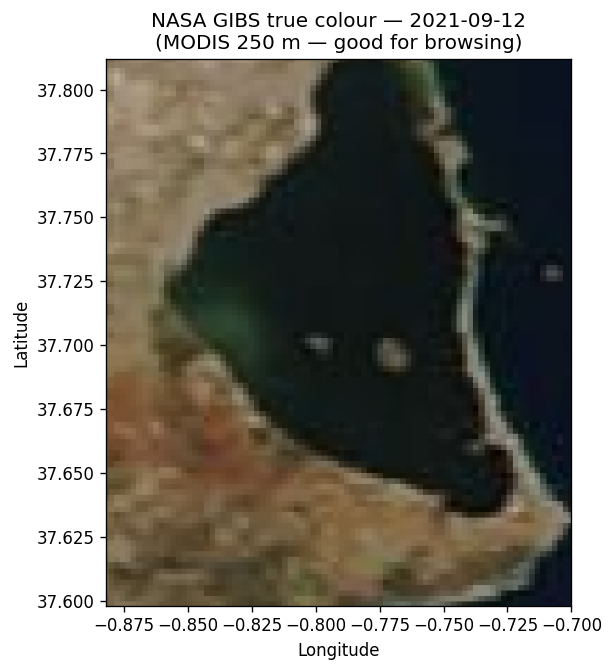

You just downloaded and displayed a real satellite image. No login.


In [2]:
DATE = "2021-09-12"      # <-- change me and re-run

def gibs_truecolor(bbox, date, w=512, h=600):
    # A WMS request is just a URL with the map you want encoded in it.
    # We paste in our bounding box, the date, and the image size, then GET it.
    url = ("https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi?"
           "SERVICE=WMS&REQUEST=GetMap&VERSION=1.3.0"
           "&LAYERS=MODIS_Terra_CorrectedReflectance_TrueColor&CRS=EPSG:4326"
           f"&BBOX={bbox[1]},{bbox[0]},{bbox[3]},{bbox[2]}"   # min/max lat,lon
           f"&WIDTH={w}&HEIGHT={h}&FORMAT=image/png&TIME={date}")
    r = requests.get(url, timeout=30)        # ask the server for the picture
    r.raise_for_status()                     # stop early if the request failed
    return mpimg.imread(io.BytesIO(r.content), format="png")  # bytes -> image array

if ONLINE:
    img = gibs_truecolor(BBOX, DATE)         # one line = one satellite image
    fig, ax = plt.subplots(figsize=(5, 6))
    ax.imshow(img, extent=[BBOX[0], BBOX[2], BBOX[1], BBOX[3]])
    ax.set_title(f"NASA GIBS true colour — {DATE}\n(MODIS 250 m — good for browsing)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); plt.show()
    print("You just downloaded and displayed a real satellite image. No login.")
else:
    print("Offline — with internet this shows a true-colour image for any date.")


---
## Step 2 — Download real Sentinel-2, only our window  🟢

GIBS was quick but coarse (250 m). For real measurement we want **Sentinel-2**:
the European Copernicus satellites that image the whole planet every ~5 days at
**10 metres per pixel** — sharp enough to see structure *inside* the lagoon.

The challenge: a single Sentinel-2 scene covers 110 × 110 km and weighs ~800 MB.
Downloading whole scenes does not scale. The professional workflow has three moves:

1. **Search a catalogue.** We query **STAC** (*SpatioTemporal Asset Catalog*) — a
   standard "search engine" for satellite imagery — asking: *which scenes cover
   this box, in this date range, with little cloud?* It replies with a list and,
   for each, the web addresses of its files. We use the free, no-login Earth
   Search catalogue, which serves the data as **L2A** (surface reflectance —
   already corrected for the atmosphere, the right product for water).
2. **Open the file's header, not the file.** The bands are stored as
   **Cloud-Optimised GeoTIFFs (COGs)** — internally tiled so you can read a small
   region over the web without fetching the whole thing.
3. **Read only our window.** We pull just the tiles overlapping our bounding box —
   a few MB instead of hundreds.

We'll grab the **12 September 2021** scene — the peak of the crisis. This cell
does step 1 (the search) and reports the scene it picked.


In [3]:
STAC = "https://earth-search.aws.element84.com/v1/search"

def find_scene(bbox, start, end, max_cloud=10):
    """Return (id, assets) of the least-cloudy Sentinel-2 scene over the bay."""
    # 'body' is our search query as a plain dictionary: which collection, which
    # box, which dates, and a filter for low cloud. We send it as JSON.
    body = {"collections": ["sentinel-2-l2a"], "bbox": list(bbox),
            "datetime": f"{start}T00:00:00Z/{end}T23:59:59Z",
            "query": {"eo:cloud_cover": {"lt": max_cloud}}, "limit": 20}
    # POST the query; .json()["features"] is the list of matching scenes.
    feats = requests.post(STAC, json=body, timeout=30).json()["features"]
    feats = [f for f in feats if "30SXG" in f["id"]]        # keep only our map tile
    # Sort by cloud cover and take the clearest one. Each scene carries 'assets':
    # a dictionary of band-name -> download URL.
    best  = sorted(feats, key=lambda f: f["properties"]["eo:cloud_cover"])[0]
    return best["id"], best["assets"]

if ONLINE:
    sid, assets = find_scene(BBOX, "2021-09-01", "2021-09-30")
    print("Chosen scene:", sid)        # e.g. S2A_30SXG_20210912_0_L2A
    print("Bands available:", [k for k in assets if k.startswith(("red","green","blue","nir","rededge"))][:6])
else:
    print("Offline — with internet this searches the catalogue and picks the clearest scene.")


Chosen scene: S2A_30SXG_20210912_0_L2A
Bands available: ['blue', 'green', 'nir', 'nir08', 'nir09', 'red']


### 2a · The real view — true colour 🟢

Now move 2 and 3: read the pixels. We start with the **natural-colour image** —
how the lagoon would look to your own eyes from orbit. Sentinel-2 ships a
ready-made True-Colour composite (the `visual` asset, made from the red, green and
blue bands), so this is the most intuitive place to begin.

**🔍 The `read_window` code, step by step** — this little function is the most
important one in the session, so here's exactly what each line does:

1. `rasterio.open(href)` — open the remote GeoTIFF, but only its **header** (a few
   KB describing size, projection, tiling). No pixels yet.
2. `transform_bounds(...)` — our box is in lon/lat degrees, but the file is in UTM
   metres. Convert the box into the file's coordinate system.
3. `from_bounds(...)` — turn those metre-coordinates into **pixel row/column
   bounds**: the rectangle of pixels we actually want.
4. `src.read(window=...)` — fetch **only that rectangle** over HTTP (plus
   `out_shape` to resample everything onto one common grid).

Notice the printed size — a few MB for a 10 m image of the whole lagoon, not the
~800 MB scene. Already in this true-colour view the bloom tints the water green.


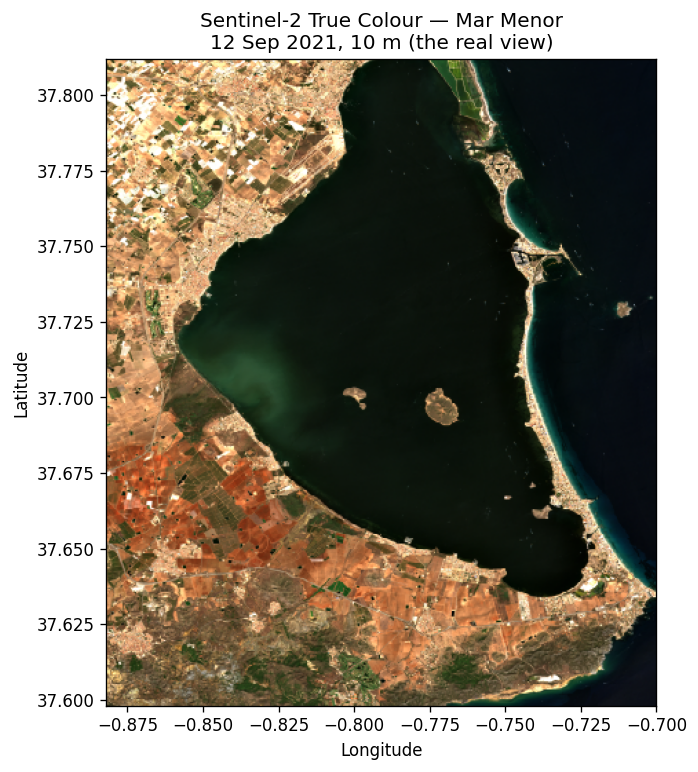

True-colour image: (470, 400, 3). The bloom already tints the water green.


In [4]:
EXT = [BBOX[0], BBOX[2], BBOX[1], BBOX[3]]
GRID = (470, 400)    # rows, cols — a common grid so every band lines up

def read_window(href, bbox, out_shape=GRID, bands=1):
    """Read just the AOI window from a remote COG (resampled to a common grid)."""
    idx = bands if isinstance(bands, list) else [1]   # which band(s) to read
    shp = (len(idx), *out_shape)
    with rasterio.open(href) as src:                  # open the remote file (header only)
        # our box is in lon/lat; the file is in UTM metres — convert the box first
        aoi = transform_bounds("EPSG:4326", src.crs, *bbox)
        # turn those map coordinates into pixel row/col bounds = the "window"
        win = from_bounds(*aoi, transform=src.transform)
        # read ONLY that window over HTTP, resampled to our common grid
        arr = src.read(idx, window=win, out_shape=shp)
    return arr[0] if bands == 1 else np.moveaxis(arr, 0, -1)  # (H,W) or (H,W,3)

if ONLINE:
    tci = read_window(assets["visual"]["href"], BBOX, bands=[1, 2, 3]).astype("uint8")
    fig, ax = plt.subplots(figsize=(6, 7))
    ax.imshow(tci, extent=EXT, origin="upper")
    ax.set_title("Sentinel-2 True Colour — Mar Menor\n12 Sep 2021, 10 m (the real view)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); plt.show()
    print(f"True-colour image: {tci.shape}. The bloom already tints the water green.")
else:
    tci = None
    print("Offline — with internet the real natural-colour image appears here.")


### 2b · The individual bands — what each wavelength sees 🟢

Here's the key idea that makes satellite *science* (not just pretty pictures)
possible: the sensor doesn't record "colour", it records **many separate
wavelength bands** — narrow slices of the spectrum, including ones your eye can't
see, like the near-infrared. True colour is just three of them (red+green+blue)
stacked together.

Each surface — water, plants, soil, an algal bloom — reflects a *different
fingerprint* across those bands. Reading the bands separately is how we tell them
apart and, in the next step, measure chlorophyll. We download five and show them
side by side. **Watch the bloom switch from dark to bright between red and
red-edge** — that flip is the whole basis of the chlorophyll index.

| Band | Wavelength | What it's sensitive to |
|------|-----------|--------------|
| **B02** blue | 490 nm | shallow water, haze/atmosphere |
| **B03** green | 560 nm | turbidity, suspended sediment |
| **B04** red | 665 nm | chlorophyll **absorbs** here → bloom looks **dark** |
| **B05** red-edge | 705 nm | chlorophyll **reflects** here → bloom looks **bright** |
| **B08** NIR | 842 nm | land & plants reflect strongly; clear water goes **black** |

Each band is read on the same grid as the others (B05 is natively 20 m, so it's
resampled to match), which is what lets us combine them pixel-by-pixel next.


Downloaded 5 bands, our window only — ~1.9 MB total.


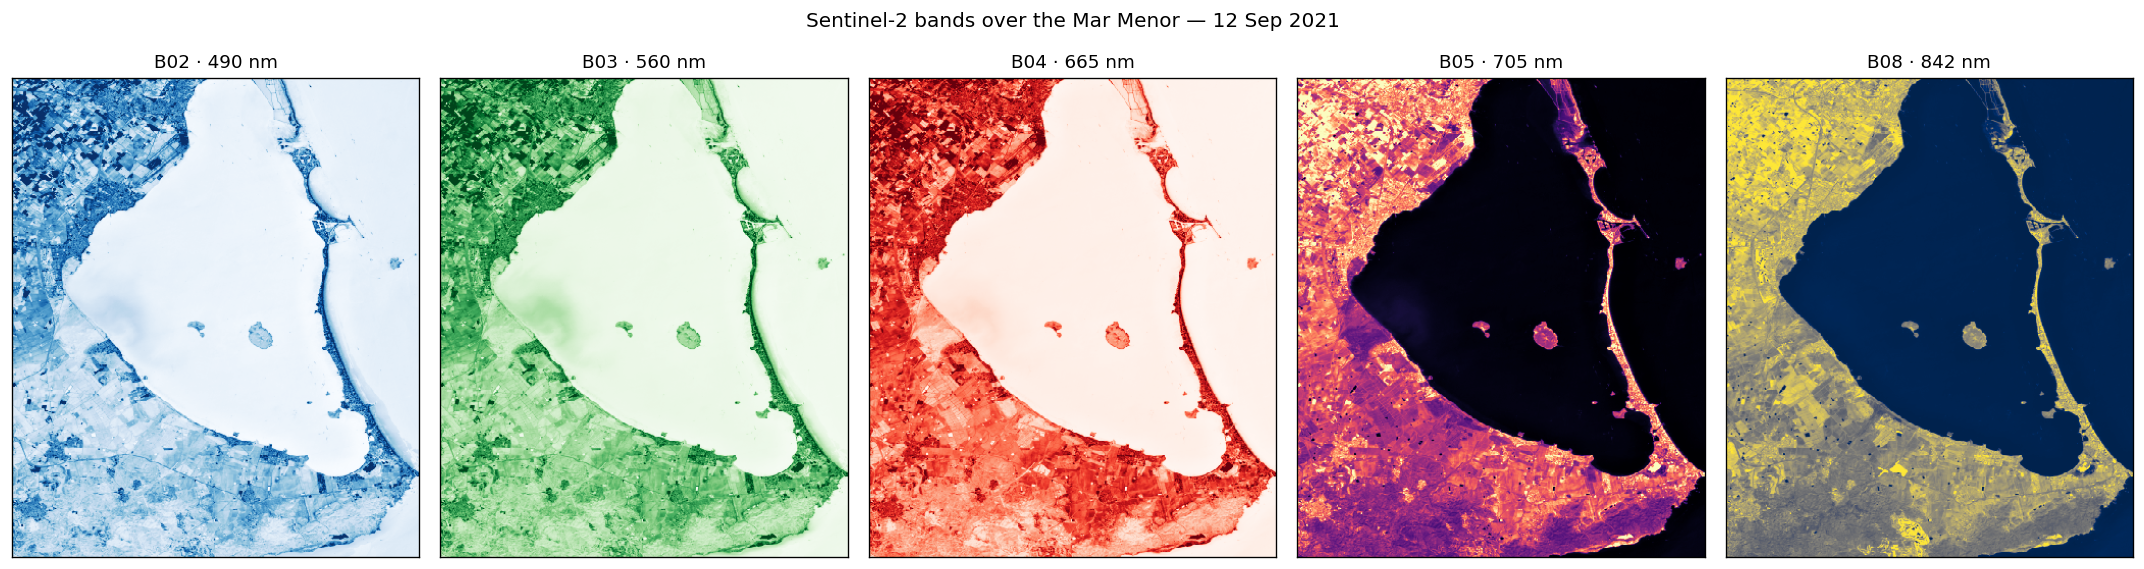

Notice: in B04 (red) the bloom is DARK (absorbed); in B05 (red-edge) it's BRIGHT.
And in B08 (NIR) the water is BLACK -- we'll use green+NIR to mask out land next.


In [5]:
BANDS = [("blue",     "B02 · 490 nm",  "Blues"),
         ("green",    "B03 · 560 nm",  "Greens"),
         ("red",      "B04 · 665 nm",  "Reds"),
         ("rededge1", "B05 · 705 nm",  "magma"),
         ("nir",      "B08 · 842 nm",  "cividis")]

if ONLINE:
    arrays = {}
    total_mb = 0
    for asset, _, _ in BANDS:
        a = read_window(assets[asset]["href"], BBOX).astype("float32")
        arrays[asset] = a
        total_mb += a.size * 2 / 1e6
    print(f"Downloaded 5 bands, our window only — ~{total_mb:.1f} MB total.")

    fig, axes = plt.subplots(1, 5, figsize=(18, 4.6))
    for ax, (asset, title, cmap) in zip(axes, BANDS):
        a = arrays[asset]
        ax.imshow(a, extent=EXT, origin="upper", cmap=cmap,
                  vmin=0, vmax=np.nanpercentile(a, 98))
        ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle("Sentinel-2 bands over the Mar Menor — 12 Sep 2021", y=1.02)
    fig.tight_layout(); plt.show()

    # Keep green, red, red-edge and NIR for the next step (all on the common grid).
    # Green + NIR give NDWI, a clean water mask (water is bright in green, dark in NIR).
    green, red, rededge, nir = arrays["green"], arrays["red"], arrays["rededge1"], arrays["nir"]
    print("Notice: in B04 (red) the bloom is DARK (absorbed); in B05 (red-edge) it's BRIGHT.")
    print("And in B08 (NIR) the water is BLACK -- we'll use green+NIR to mask out land next.")
else:
    green = red = rededge = nir = None
    print("Offline — with internet five real bands arrive here (~2 MB).")


---
## Step 3 — Measure the bloom with NDCI  🟢

A picture shows *where* the water looks green; an **index** turns that into a
**number** at every pixel, so you can compare dates, map gradients and set
thresholds. The standard one for chlorophyll in coastal water is the **NDCI**
(Normalized Difference Chlorophyll Index):

$$\text{NDCI} = \frac{B05 - B04}{B05 + B04}$$

**Why this formula works.** Chlorophyll *absorbs* red light (B04) and *reflects*
the red-edge (B05) — exactly the dark→bright flip you just saw in Step 2b. So
`B05 − B04` grows as there's more chlorophyll. Dividing by `B05 + B04`
**normalises** it: the result always sits between −1 and +1 and cancels out
effects like overall brightness or sun angle, so values are comparable across
images. (This "difference over sum" trick is the same idea behind NDVI for
vegetation.)

**How to read the map:** blue ≈ clear water (low/negative NDCI); red/yellow ≈
active bloom (high NDCI). To keep the focus on the lagoon we first build a **water
mask** with NDWI — water is bright in green and black in the NIR band (B08) you saw
in Step 2b, so `(green − NIR) / (green + NIR) > 0` isolates it — and grey out the land. What's left is the
September 2021 crisis, measured pixel by pixel. Notice it's strongest in the
**north-west**, exactly where the Campo de Cartagena drains into the lagoon. The
median we print is one number you could drop straight into a database (Step 7).


C:\Users\Despacho 1\AppData\Local\Temp\ipykernel_26056\3814811640.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("turbo").copy(); cmap.set_bad("#e9e4d8")   # land = soft grey


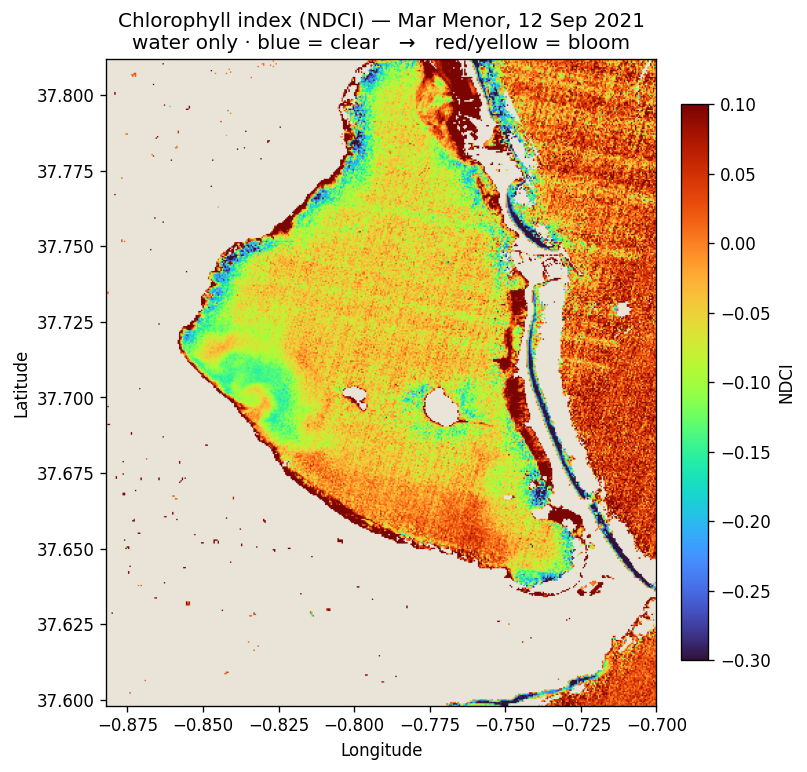

Median NDCI over the lagoon water: -0.036
Highest in the north-west — where the agricultural watershed drains in.


In [6]:
if ONLINE and red is not None:
    # Water mask via NDWI (green vs NIR): water is bright in green, dark in NIR,
    # so NDWI > 0 means water. Robust, and the same idea the Step-5 evalscript uses.
    ndwi  = (green - nir) / (green + nir + 1e-6)
    water = (ndwi > 0) & (red > 30)
    ndci  = np.where(water, (rededge - red) / (rededge + red + 1e-6), np.nan)

    import matplotlib.cm as cm
    cmap = cm.get_cmap("turbo").copy(); cmap.set_bad("#e9e4d8")   # land = soft grey
    fig, ax = plt.subplots(figsize=(6.5, 7))
    ax.set_facecolor("#e9e4d8")
    im = ax.imshow(np.ma.masked_invalid(ndci), cmap=cmap, vmin=-0.3, vmax=0.1,
                   extent=[BBOX[0], BBOX[2], BBOX[1], BBOX[3]])
    ax.set_title("Chlorophyll index (NDCI) — Mar Menor, 12 Sep 2021\n"
                 "water only · blue = clear   →   red/yellow = bloom")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.colorbar(im, ax=ax, label="NDCI", fraction=0.046, pad=0.04); plt.show()
    print(f"Median NDCI over the lagoon water: {np.nanmedian(ndci):+.3f}")
    print("Highest in the north-west — where the agricultural watershed drains in.")
else:
    print("Offline — with internet this is the NDCI chlorophyll map of the bloom.")


---
## Step 4 — Pollution context: live air quality  🟢

Satellites are not the only free data, and "pollution" is more than water colour.
Real monitoring combines sources. Here we add **air quality** — the dust and
aerosols over the Campo de Cartagena, the same agricultural basin whose nutrient
runoff feeds the lagoon's blooms.

The **Open-Meteo Air-Quality API** gives hourly **PM2.5** and **PM10**
(fine/coarse particulate matter, the standard health metrics) and **ozone** for
any coordinate on Earth — no key, no sign-up. This is a different *shape* of data
from the satellite imagery: not a grid of pixels but a **time series** returned as
JSON, which we load straight into a pandas DataFrame and plot. Same universal
pattern, though: *ask a server for a subset, get data back, analyse it.*


Received 192 hourly rows. Latest PM2.5 = 8.4 ug/m3


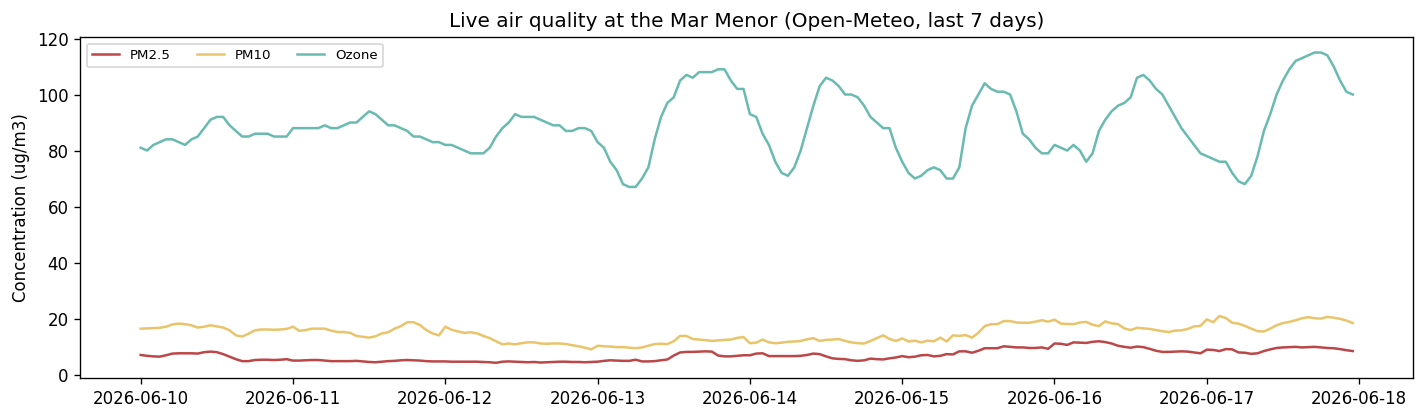

In [7]:
def air_quality(lat, lon, past_days=7):
    url = ("https://air-quality-api.open-meteo.com/v1/air-quality?"
           f"latitude={lat}&longitude={lon}"
           f"&hourly=pm10,pm2_5,ozone&past_days={past_days}&forecast_days=1")
    h = requests.get(url, timeout=30).json()["hourly"]
    df = pd.DataFrame(h); df["time"] = pd.to_datetime(df["time"]); return df

if ONLINE:
    aq = air_quality(LAGOON_LAT, LAGOON_LON)
    print(f"Received {len(aq)} hourly rows. Latest PM2.5 = {aq['pm2_5'].iloc[-1]:.1f} ug/m3")
    fig, ax = plt.subplots(figsize=(12, 3.6))
    ax.plot(aq["time"], aq["pm2_5"], label="PM2.5", color="#bc4749")
    ax.plot(aq["time"], aq["pm10"],  label="PM10",  color="#e9c46a")
    ax.plot(aq["time"], aq["ozone"], label="Ozone", color="#2a9d8f", alpha=.7)
    ax.set_ylabel("Concentration (ug/m3)")
    ax.set_title("Live air quality at the Mar Menor (Open-Meteo, last 7 days)")
    ax.legend(ncol=3, fontsize=8); fig.tight_layout(); plt.show()
else:
    print("Offline — with internet this is a live 7-day PM2.5 / PM10 / ozone series.")


---
## Step 5 — (Optional) your free Copernicus key  ✏️ ⏭️

So far we *downloaded raw bands and computed the index ourselves*. That's great for
learning, but there's a more powerful mode. A free **Copernicus** account unlocks
**server-side processing**: instead of pulling pixels, you send the server a tiny
recipe and it returns the *finished product* — for example an NDCI map for any
date — having done the heavy lifting in the cloud.

Two services do this:
- **Process API** — you send an **evalscript** (a few lines of JavaScript saying
  *"for each pixel, compute this"*) and get back a ready image.
- **Statistical API** — returns a whole **time series** over your area in one
  request, downloading *no imagery at all* — the cheap way to run a dashboard.

**Set it up in 3 minutes, live:**

1. **Register.** Go to **<https://dataspace.copernicus.eu>** → *Register* (top
   right). Enter an email + password, accept the terms, and click the link in the
   confirmation email. Free, no credit card, ~30,000 processing units/month.
2. **Create an OAuth client.** Log in, then open the **Sentinel Hub dashboard**:
   <https://shapps.dataspace.copernicus.eu/dashboard/> → top-right user menu →
   **User settings** → scroll to **OAuth clients** → **"Create"**. Give it any
   name. It shows a **Client ID** and a **Client secret**.
   - ⚠️ The **secret appears only once** — copy it immediately. If you lose it,
     just delete the client and create a new one.
3. **Authenticate.** Run the next cell and paste the two values when asked.

**What is OAuth, really?** Think of the Client ID + secret as a *username and
password for your code* (not for you). Your code sends them once and gets back a
**token** — a temporary badge (valid ~10 min) that it clips to every request to
prove it's allowed. We never hard-code the secret into the notebook; we paste it
into a hidden prompt so it doesn't end up saved in the file.

**If it doesn't work:**
- `401 / invalid_client` → the ID or secret was mistyped, or the client was
  deleted. Re-copy them, or make a new OAuth client.
- *Worked earlier, fails now* → the token expired (~10 min). Just re-run this cell
  to get a fresh one.
- *Later cells say "skipped"* → you pressed Enter without pasting; re-run and paste.

> ⏭️ Entirely optional. Skip it (just press Enter) and the session is still
> complete — Steps 1–4 stand on their own with no account.


In [8]:
import os, getpass

def cdse_token(cid, csec):
    # Exchange your ID + secret for a short-lived access token (OAuth2).
    # The token is what every later request shows as proof you're logged in.
    r = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/"
        "protocol/openid-connect/token",
        data={"grant_type": "client_credentials",
              "client_id": cid, "client_secret": csec}, timeout=30)
    r.raise_for_status(); return r.json()["access_token"]

# Read credentials from the environment if set; otherwise ask for them now.
CID  = os.environ.get("CDSE_CLIENT_ID")
CSEC = os.environ.get("CDSE_CLIENT_SECRET")
if not (CID and CSEC):
    try:
        CID  = input("Client ID (Enter to skip): ").strip()
        CSEC = getpass.getpass("Client secret (hidden): ").strip()  # hidden as you paste
    except Exception:
        CID = CSEC = ""                  # non-interactive run: just skip

TOKEN = None
if CID and CSEC:
    try:
        TOKEN = cdse_token(CID, CSEC)
        print("Authenticated with CDSE — token acquired (valid ~10 min).")
    except Exception as e:
        print("Authentication failed:", e)
else:
    print("Skipped — no credentials entered. The session is complete without this.")


Authenticated with CDSE — token acquired (valid ~10 min).


With a token, the **Process API** runs an *evalscript* (what each pixel
should be) on the server and returns a ready NDCI GeoTIFF for any date — no bands
downloaded. Runs only if you authenticated above.

**🔍 The code, step by step** — two pieces:

1. **The evalscript** (the JavaScript string). `setup()` lists the bands we want as
   input and how many we return; `evaluatePixel(s)` runs *for every pixel* — here
   it computes NDCI, computes NDWI, and returns the NDCI only where NDWI says
   "water". This is the **recipe** the server runs for us.
2. **The request body** (the Python dict). It bundles three things: *where*
   (`bounds`/bbox), *what + when* (`data`: Sentinel-2, this date), and *how big*
   (`output`: width/height), plus the evalscript. We `requests.post` it with our
   token in the header, and get back a GeoTIFF — which `rasterio` opens like any
   other image.

So the masking happens **on the server**: the result arrives already focused on
the lagoon — the same clean map as Step 3, but computed in the cloud.


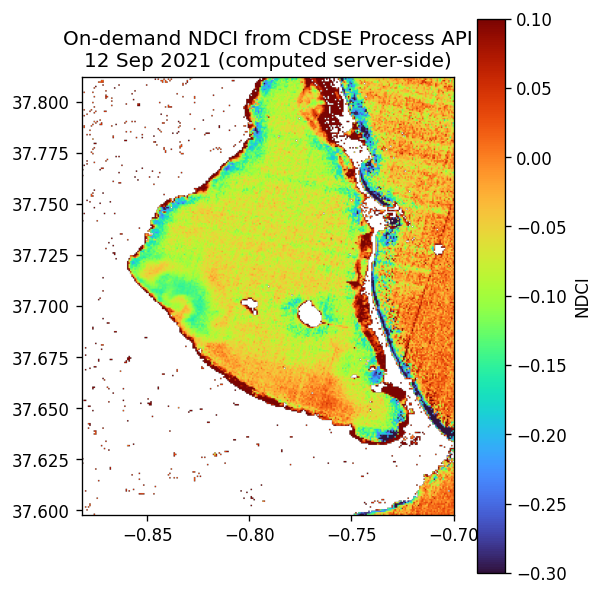

CDSE computed this and sent only the result — no bands downloaded.


In [9]:
EVALSCRIPT = """//VERSION=3
function setup(){return {input:["B03","B04","B05","B08","dataMask"],
  output:{bands:2, sampleType:"FLOAT32"}};}
function evaluatePixel(s){
  let ndci = (s.B05 - s.B04) / (s.B05 + s.B04);
  let ndwi = (s.B03 - s.B08) / (s.B03 + s.B08);   // > 0 over water
  let water = ndwi > 0 ? 1 : 0;
  return [ndci, s.dataMask * water];}"""

def process_ndci(token, bbox, date, size=(256, 300)):
    body = {"input": {"bounds": {"bbox": list(bbox),
              "properties": {"crs": "http://www.opengis.net/def/crs/EPSG/0/4326"}},
              "data": [{"type": "sentinel-2-l2a",
                        "dataFilter": {"timeRange": {"from": f"{date}T00:00:00Z",
                                                     "to": f"{date}T23:59:59Z"}}}]},
            "output": {"width": size[0], "height": size[1],
                       "responses": [{"identifier": "default",
                                      "format": {"type": "image/tiff"}}]},
            "evalscript": EVALSCRIPT}
    r = requests.post("https://sh.dataspace.copernicus.eu/api/v1/process",
                      json=body, headers={"Authorization": f"Bearer {token}"}, timeout=60)
    r.raise_for_status(); return r.content

if TOKEN:
    tif = process_ndci(TOKEN, BBOX, "2021-09-12")
    with rasterio.open(io.BytesIO(tif)) as src:
        arr, mask = src.read(1), src.read(2)
    ndci_live = np.where(mask > 0, arr, np.nan)
    fig, ax = plt.subplots(figsize=(5, 6))
    im = ax.imshow(ndci_live, cmap="turbo", vmin=-0.3, vmax=0.1,
                   extent=[BBOX[0], BBOX[2], BBOX[1], BBOX[3]])
    ax.set_title("On-demand NDCI from CDSE Process API\n12 Sep 2021 (computed server-side)")
    plt.colorbar(im, ax=ax, label="NDCI"); plt.show()
    print("CDSE computed this and sent only the result — no bands downloaded.")
else:
    print("[skipped] With a token, a ready NDCI map for any date arrives here.")


### 5b · A water-quality panel — three products in one request 🟢 ⏭️

Here's the real power of the Process API: **one evalscript can return several
products at once.** Remember from the workshop intro that "Case-2" water like the
Mar Menor is optically driven by **three** things — phytoplankton, suspended
sediment, and coloured dissolved organic matter (CDOM). We can map all three
*separately*, plus the true-colour reference, from a single server call:

| Panel | Product | What it shows |
|-------|---------|---------------|
| 1 | **True colour** | the natural view, for reference |
| 2 | **Chlorophyll (NDCI)** | phytoplankton — the overall algal signal |
| 3 | **Bloom hotspots (MCI)** | Maximum Chlorophyll Index — where the bloom is *most intense* |
| 4 | **Turbidity (FNU)** | suspended sediment — how murky the water is (Dogliotti 2015) |
| 5 | **CDOM (green/blue)** | dissolved organic matter — "tea-coloured" runoff |

One request, five views of the same water. NDCI shows *where there's chlorophyll*;
**MCI** sharpens that to *where the bloom peaks* (it measures the red-edge "bump"
that only dense surface blooms produce). This is how an analyst builds a
water-quality dashboard.


C:\Users\Despacho 1\AppData\Local\Temp\ipykernel_26056\1071583384.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name).copy(); cmap.set_bad("#e9e4d8")


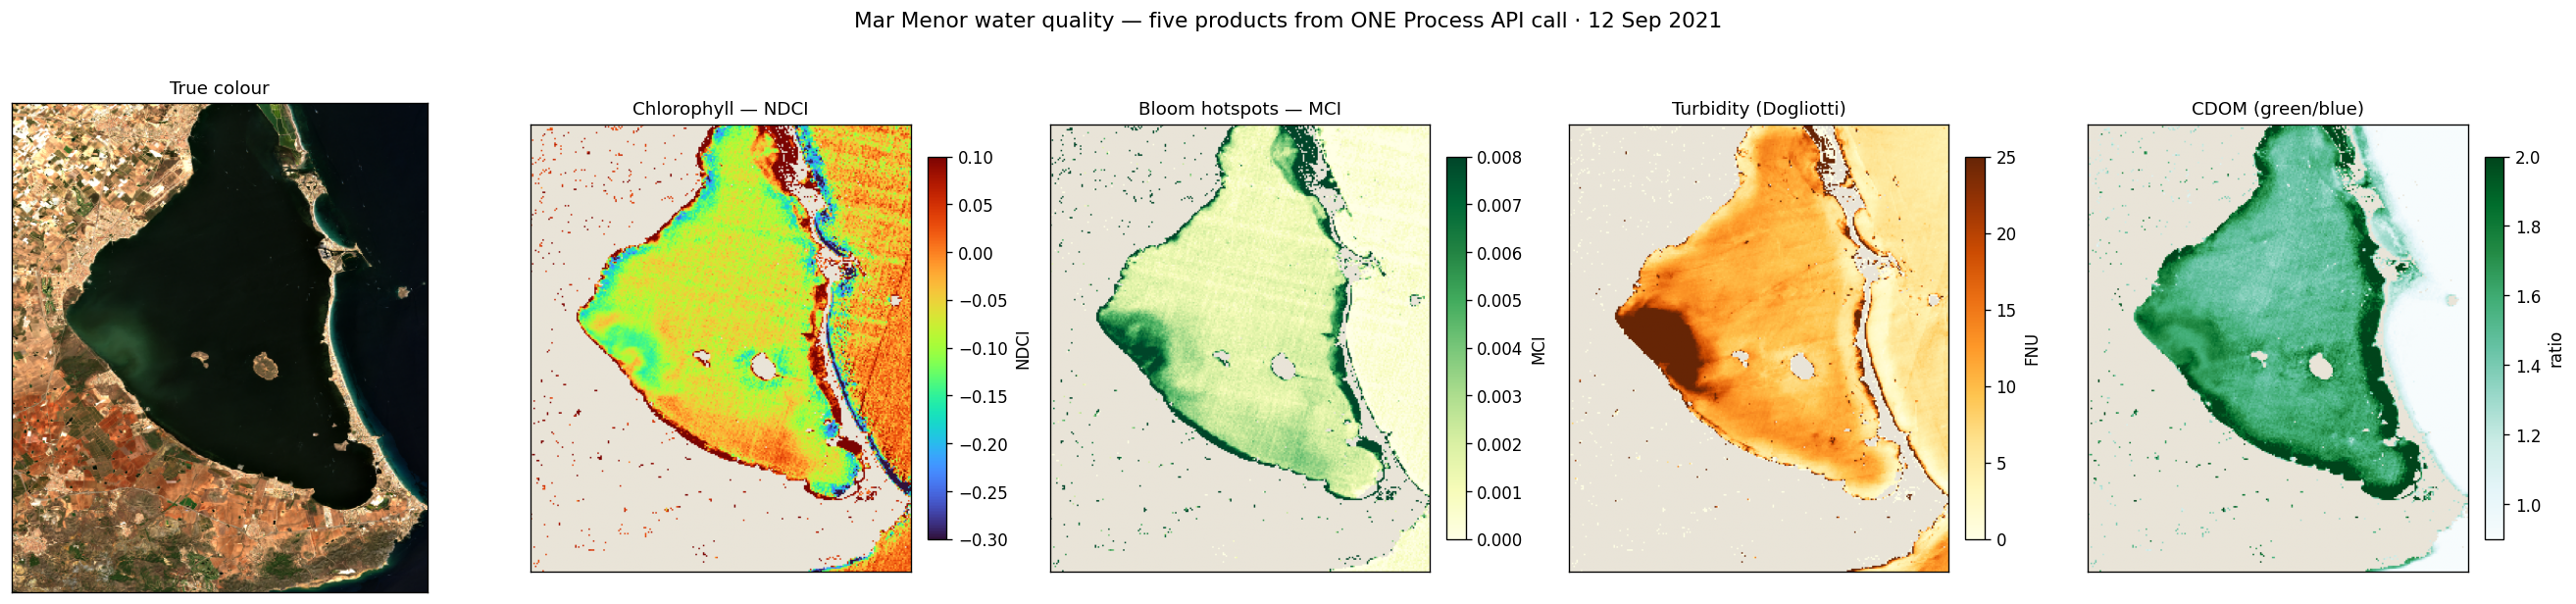

Lagoon medians -> NDCI -0.061 | MCI 0.0014 | turbidity 9.3 FNU | CDOM 1.47
NDCI + MCI map the algae (overall vs peak), turbidity the sediment, CDOM the dissolved organics.


In [10]:
# ONE evalscript -> five bands: NDCI, MCI, turbidity (FNU), CDOM, water mask
EVAL_WQ = """//VERSION=3
function setup(){return {input:["B02","B03","B04","B05","B06","B08","dataMask"],
  output:{bands:5, sampleType:"FLOAT32"}};}
function evaluatePixel(s){
  let ndci = (s.B05 - s.B04) / (s.B05 + s.B04);          // chlorophyll
  let mci  = s.B05 - s.B04 - (s.B06 - s.B04) * 0.533;    // bloom peak (red-edge)
  let rho  = s.B04 * 3.14159;
  let turb = (228.1 * rho) / (1.0 - rho / 0.1641);       // turbidity, FNU
  let cdom = s.B03 / s.B02;                              // CDOM proxy (green/blue)
  let ndwi = (s.B03 - s.B08) / (s.B03 + s.B08);
  return [ndci, mci, turb, cdom, s.dataMask * (ndwi > 0 ? 1 : 0)];}"""

def process_wq(token, bbox, date, size=(256, 300)):
    body = {"input": {"bounds": {"bbox": list(bbox),
              "properties": {"crs": "http://www.opengis.net/def/crs/EPSG/0/4326"}},
              "data": [{"type": "sentinel-2-l2a",
                        "dataFilter": {"timeRange": {"from": f"{date}T00:00:00Z",
                                                     "to": f"{date}T23:59:59Z"}}}]},
            "output": {"width": size[0], "height": size[1],
                       "responses": [{"identifier": "default",
                                      "format": {"type": "image/tiff"}}]},
            "evalscript": EVAL_WQ}
    r = requests.post("https://sh.dataspace.copernicus.eu/api/v1/process",
                      json=body, headers={"Authorization": f"Bearer {token}"}, timeout=60)
    r.raise_for_status(); return r.content

if TOKEN:
    import matplotlib.cm as cm
    with rasterio.open(io.BytesIO(process_wq(TOKEN, BBOX, "2021-09-12"))) as src:
        wq = src.read()                  # (5,H,W): ndci, mci, turb, cdom, mask
    water = (wq[4] > 0) & np.all(np.isfinite(wq[:4]), axis=0)
    def masked(b): return np.ma.masked_where(~water, b)

    panels = [
        ("Chlorophyll — NDCI",    masked(wq[0]), "turbo",  -0.3, 0.1,   "NDCI"),
        ("Bloom hotspots — MCI",  masked(wq[1]), "YlGn",    0,   0.008, "MCI"),
        ("Turbidity (Dogliotti)", masked(wq[2]), "YlOrBr",  0,   25,    "FNU"),
        ("CDOM (green/blue)",     masked(wq[3]), "BuGn",    0.9, 2.0,   "ratio"),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(22, 5.0))
    ax = axes[0]                          # Panel 1: true colour (from Step 2a)
    if "tci" in dir() and tci is not None:
        ax.imshow(tci, extent=EXT, origin="upper")
    ax.set_title("True colour", fontsize=11); ax.set_xticks([]); ax.set_yticks([])
    for ax, (title, data, cmap_name, vmin, vmax, unit) in zip(axes[1:], panels):
        cmap = cm.get_cmap(cmap_name).copy(); cmap.set_bad("#e9e4d8")
        ax.set_facecolor("#e9e4d8")
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, extent=EXT, origin="upper")
        ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=unit)
    fig.suptitle("Mar Menor water quality — five products from ONE Process API call · 12 Sep 2021",
                 y=1.04, fontsize=13)
    fig.tight_layout(); plt.show()
    print(f"Lagoon medians -> NDCI {np.ma.median(masked(wq[0])):+.3f} | "
          f"MCI {np.ma.median(masked(wq[1])):.4f} | "
          f"turbidity {np.ma.median(masked(wq[2])):.1f} FNU | "
          f"CDOM {np.ma.median(masked(wq[3])):.2f}")
    print("NDCI + MCI map the algae (overall vs peak), turbidity the sediment, CDOM the dissolved organics.")
else:
    print("[skipped] With a token, a 5-panel water-quality dashboard arrives here.")


---
## Step 6 — A taste of machine learning  🟢

So far we've worked with **images**. But the agencies that manage the lagoon also
run **buoys in the water** that report *every single day*: temperature, salinity,
chlorophyll, turbidity, dissolved oxygen and nitrate — six numbers, daily, for a
decade. That's ~22,000 readings. Buried in them is the signal of every crisis.
The problem: **how do you spot "today is abnormal" across six variables at once?**
A single threshold (say, chlorophyll > 5) misses the subtle combinations — slightly
high chlorophyll *and* low oxygen *and* warm water together. This is exactly the
job machine learning is good at.

### The idea: teach a model what "normal" looks like

We use an **Isolation Forest**. Forget the name for a second — the intuition is
simple. Imagine plotting every day as a point in a 6-dimensional space (one axis
per variable). Normal days cluster together in a dense cloud; a crisis day sits
far out on its own. The algorithm plays a game: it makes **random cuts** through
the data and counts how many cuts it takes to isolate each point.

- A **normal** day is deep inside the crowd → it needs *many* cuts to isolate → it
  looks ordinary.
- An **anomalous** day is off on its own → a *few* cuts already isolate it → it
  gets flagged.

It's **unsupervised**: we never tell it when the crises were. We only show it
*normal* and let it react to anything different.

### The honest part: train on calm years, test on everything

The catch with "detecting" past events is that it's easy to cheat — if the model
sees the crises during training, "finding" them later proves nothing. So:

- **Train only on 2017–2018**, two quiet years. The model learns the lagoon's
  normal seasonal rhythm and *never sees* 2019 or 2021.
- **Then score every day from 2019 on.** Anything it flags is a genuine
  *out-of-sample* discovery — the same position a real early-warning system is in.

### How to read the plot

The line is the **anomaly score** for each day (**lower = stranger**). Red dots
are days the model flags. Blue shading = the calm training window; orange shading =
the documented crises (2019 DANA, 2021 fish-kill, 2025 bloom). **If the method
works, the red dots should pile up inside the orange bands** — the model
rediscovering the crises on its own, having never been told they happened.

> A 5-minute taste. Notebook **02** does it rigorously: validating satellite
> against buoys, honest cross-validation, and turning these flags into a real
> *lead time* — how many days of warning you'd actually get before a crisis hits.


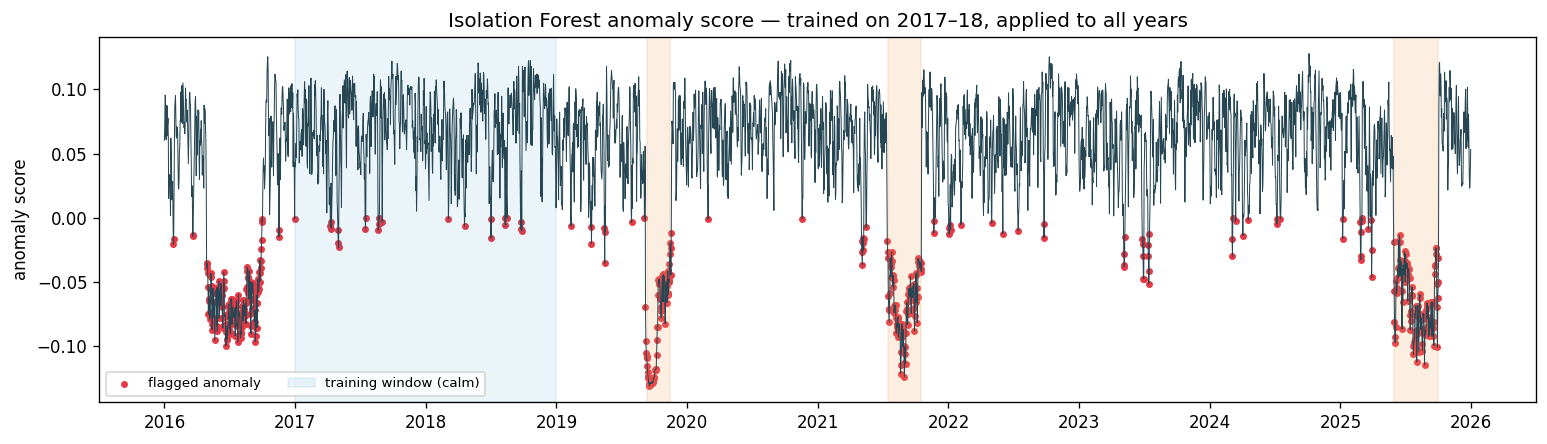

Inside the 282 documented crisis days, the model flagged 282 (100%) — caught the disasters it never trained on.
It also raises some false alarms in calmer periods (total flags: 546).
Trading off catches vs false alarms is exactly what Notebook 02 does rigorously.


In [11]:
from sklearn.ensemble import IsolationForest

buoys = load_parquet("insitu_buoys_2016_2025.parquet")   # the daily buoy table
buoys["date"] = pd.to_datetime(buoys["date"])

# Average the stations into one daily value per variable, smoothed over a week
# to damp day-to-day sensor noise. Each row is now "the lagoon on day X".
VARS = ["sst_C", "salinity_psu", "chla_mg_m3", "turbidity_FNU", "do_mg_L", "nitrate_mg_L"]
daily = buoys.groupby("date")[VARS].mean().rolling(7, min_periods=1, center=True).mean()
daily = daily.dropna()

# Fit ONLY on the quiet baseline, then score everything (honest early warning).
train = daily.loc["2017-01-01":"2018-12-31"]
iso = IsolationForest(n_estimators=300, contamination=0.03, random_state=42)
iso.fit(train)                                           # learn what "normal" is
# decision_function gives each day a score; lower = more unlike the calm baseline.
score = pd.Series(iso.decision_function(daily), index=daily.index)

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(score.index, score.values, lw=.6, color="#264653")
flagged = score[iso.predict(daily) == -1]
ax.scatter(flagged.index, flagged.values, s=10, color="#e63946", label="flagged anomaly")
for s, e in [("2019-09-10","2019-11-15"), ("2021-07-15","2021-10-15"), ("2025-06-01","2025-09-30")]:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="#f4a261", alpha=.18)
ax.axvspan("2017-01-01","2018-12-31", color="#0077b6", alpha=.08, label="training window (calm)")
ax.set_title("Isolation Forest anomaly score — trained on 2017–18, applied to all years")
ax.set_ylabel("anomaly score"); ax.legend(loc="lower left", fontsize=8, ncol=2)
fig.tight_layout(); plt.show()

# Quantify it: of the documented crisis days, how many did the model catch?
crisis = [("2019-09-10","2019-11-15"), ("2021-07-15","2021-10-15"), ("2025-06-01","2025-09-30")]
flagged_set = set(flagged.index)
crisis_days = [d for d in daily.index
               if any(pd.Timestamp(s) <= d <= pd.Timestamp(e) for s, e in crisis)]
caught = sum(d in flagged_set for d in crisis_days)
print(f"Inside the {len(crisis_days)} documented crisis days, the model flagged "
      f"{caught} ({100*caught/len(crisis_days):.0f}%) — caught the disasters it never trained on.")
print(f"It also raises some false alarms in calmer periods (total flags: {len(flagged)}).")
print("Trading off catches vs false alarms is exactly what Notebook 02 does rigorously.")


---
## Step 7 — Build a tiny database  🟢

A measurement that lives only in a Python variable disappears when you close the
notebook. A real project **stores** it, so it can sit next to years of other
observations and be queried later. This last step shows the whole idea in
miniature.

We use **SQLite**: a complete database that is just a single file (it's built into
Python — nothing to install, and it's the same engine inside your phone and
browser). We:

1. Create one table, `observations`, with a sensible shape — *one row per
   (date, source, variable, value)*. This "long" layout makes everything easy to
   query and combine.
2. Insert **the NDCI you measured live in Step 3** — tagged as a `sentinel2_live`
   observation — right alongside the historical chlorophyll series.
3. Ask a question in **SQL**, the standard language of databases: *which years had
   the worst chlorophyll?* The answer comes back sorted, and the documented crises
   rise to the top — computed by the database, not by us.

That's the leap from "I made a plot" to "I have a dataset other people can query."

> A 5-minute preview. Notebook **03** builds the real thing: cloud-masking, Parquet
> for the bulky per-pixel arrays, *idempotent* updates (safe to re-run on a
> schedule), and a full pollution study — plus when to graduate to PostGIS/DuckDB.


In [12]:
# Open a database. ":memory:" keeps it in RAM for the demo; use "marmenor.db"
# for a real file on disk. 'con' is our connection to run SQL through.
con = sqlite3.connect(":memory:")
# Define the table: four columns. UNIQUE(...) means re-inserting the same
# (date, source, variable) updates that row instead of duplicating it.
con.execute("""CREATE TABLE observations(
    date TEXT, source TEXT, variable TEXT, value REAL,
    UNIQUE(date, source, variable))""")

# 1) the value YOU just measured live in Step 3 (the ? are filled in safely)
live_ndci = float(np.nanmedian(ndci)) if (ONLINE and red is not None) else 0.056
con.execute("INSERT OR REPLACE INTO observations VALUES (?,?,?,?)",
            ("2021-09-12", "sentinel2_live", "ndci", round(live_ndci, 4)))

# 2) the synthetic chlorophyll series (monthly lagoon mean) as historical context
s2 = load_parquet("sentinel2_waterquality.parquet")
s2["date"] = pd.to_datetime(s2["date"])
monthly = (s2.assign(m=s2["date"].dt.strftime("%Y-%m"))
             .groupby("m")["chla_mg_m3"].mean())
con.executemany("INSERT OR REPLACE INTO observations VALUES (?,?,?,?)",
                [(m+"-15", "sentinel2_synthetic", "chla_mg_m3", round(v, 3))
                 for m, v in monthly.items()])
con.commit()
print(f"Stored {con.execute('SELECT COUNT(*) FROM observations').fetchone()[0]} observations.")

# One SQL query: rank the years by peak chlorophyll — the crises jump out
q = """SELECT substr(date,1,4) AS year,
              ROUND(MAX(value), 1) AS peak_chla,
              ROUND(AVG(value), 2) AS mean_chla
       FROM observations WHERE variable='chla_mg_m3'
       GROUP BY year ORDER BY peak_chla DESC LIMIT 5"""
print("Worst years by peak monthly chlorophyll (one SQL query):")
print(pd.read_sql(q, con).to_string(index=False))
print("\n2019 and 2021 — the documented crises — top the list, straight from SQL.")
print("And your live NDCI measurement is row 1 of the same queryable database.")
con.close()


Stored 108 observations.
Worst years by peak monthly chlorophyll (one SQL query):
year  peak_chla  mean_chla
2019       10.2       2.91
2021        7.9       2.94
2025        3.8       2.68
2024        3.7       1.99
2023        3.6       2.03

2019 and 2021 — the documented crises — top the list, straight from SQL.
And your live NDCI measurement is row 1 of the same queryable database.


---
## Wrap-up — what you just did

In one hour, with no install and (mostly) no account, you:

1. **Browsed** any date from orbit (NASA GIBS).
2. **Downloaded** real 10 m Sentinel-2 — the true-colour view and the individual bands (the COG trick).
3. **Measured** the 2021 bloom with the NDCI chlorophyll index.
4. **Added** live pollution context (air quality).
5. *(Optional)* Pulled an **on-demand product** from Copernicus with your own key.
6. Trained a **machine-learning detector** that flagged the crises on its own.
7. Stored your measurement in a **database** and queried it in SQL.

The pattern is universal: **discover → request a subset → get an array → analyse → store.**
Change two numbers — the area `AOI` and the `DATE` — and this exact notebook works
for any coast, lake or river on Earth. The story you watched unfold over the Mar
Menor, you can now tell about your own study site.

That is the real takeaway: the data that documented an ecological disaster is
**free, open, and one `requests.get()` away**. The barrier was never access — it's
knowing how to ask. Now you do.

## Go further — optional extra material

The full workshop has three deeper notebooks in this same repo:

| Notebook | What it adds |
|----------|--------------|
| **01 — Satellite data extraction** | C2RCC vs L2A, Sentinel-3 SST, the heatwave→oxygen mechanism, zone analysis |
| **02 — In-situ + machine learning** | buoy match-ups, honest cross-validation, anomaly detection & early warning |
| **03 — Build your own database** | the full pipeline: clean → SQLite + Parquet → a pollution study in SQL |

Open any of them from the repository README. Same one-click Colab badges.
